<a href="https://colab.research.google.com/github/gbanharo/heart-disease-mvp/blob/main/GuilhermeBanharo_MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Guilherme Montenegro Banharo  
**Matrícula:** _Sua matrícula aqui_  
**Data:** _dd/mm/aaaa_  
**Dataset:** _Logistic regression To predict heart disease
Link:https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression?resource=download_  
**Tipo de problema:** _Classificação / Regressão / Clusterização / Séries Temporais_  

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

As doenças cardiovasculares estão entre as principais causas de mortalidade no mundo. A identificação precoce de indivíduos com maior risco de desenvolver doença coronariana pode auxiliar profissionais de saúde na adoção de medidas preventivas e no acompanhamento adequado dos pacientes. Neste projeto será utilizada uma base de dados contendo informações clínicas e demográficas para prever a ocorrência de doença cardíaca em um horizonte de dez anos.



## 1.2 Objetivo do MVP



**Objetivo deste trabalho:**  
> O objetivo deste MVP é desenvolver e avaliar modelos de Machine Learning capazes de prever a ocorrência de doença coronariana nos próximos dez anos com base em características clínicas e demográficas dos pacientes.


## 1.3 Tipo de problema

Indique o tipo de problema e justifique.

- **Classificação:** prever uma classe/categoria.
- **Regressão:** prever um valor numérico contínuo.
- **Clusterização:** agrupar exemplos similares sem rótulo conhecido.
- **Séries temporais / forecasting:** prever valores futuros respeitando a ordem temporal.

**Tipo escolhido:** Classificação supervisionada binária  
**Justificativa:** O objetivo deste projeto é prever se um paciente desenvolverá ou não doença coronariana nos próximos dez anos. A variável alvo utilizada é TenYearCHD (Ten Year Coronary Heart Disease), que possui apenas dois valores possíveis: 0 (não desenvolverá a doença) e 1 (desenvolverá a doença). Como o modelo deve prever uma categoria entre duas classes a partir de exemplos previamente rotulados, este problema é caracterizado como uma tarefa de classificação supervisionada binária.

>


## 1.4 Premissas, hipóteses e critérios de sucesso


**Hipóteses iniciais:**
1. _Pacientes com idade mais avançada apresentam maior probabilidade de desenvolver doença coronariana._
2. _Níveis elevados de colesterol estão associados a um maior risco cardiovascular._
3. _Pacientes hipertensos tendem a apresentar maior incidência de doença coronariana._
4. _O tabagismo contribui significativamente para o aumento do risco cardíaco._
5. _A presença de diabetes está associada a uma maior probabilidade de ocorrência da doença._


**Critérios de sucesso:**
- Métrica principal: _F1-score e ROC-AUC._
- Resultado mínimo esperado: _Superar o desempenho do modelo baseline (DummyClassifier)._
- Restrição prática: _Manter um tempo de treinamento baixo e utilizar modelos interpretáveis e reproduzíveis._

> .


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [2]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [2]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descreva a base escolhida.

**O que incluir:**
- Framingham Heart Disease Dataset
- https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression?resource=download
- Este dataset foi escolhido por abordar um problema real da área da saúde, que é a previsão do risco de desenvolvimento de doença coronariana nos próximos dez anos. A base contém variáveis clínicas e comportamentais relevantes, como idade, sexo, pressão arterial, colesterol, diabetes e hábitos de tabagismo, permitindo a aplicação de técnicas de Machine Learning para classificação de risco cardiovascular.
- A base apresenta alguns valores ausentes que deverão ser tratados durante o pré-processamento dos dados. Além disso, os dados foram coletados em uma população específica do estudo Framingham, podendo haver limitações na generalização dos resultados para outras populações. O dataset foi obtido de uma fonte pública e utilizado para fins acadêmicos.
- Os dados disponibilizados são anonimizados e públicos para fins educacionais e de pesquisa, não contendo informações que permitam identificar indivíduos específicos. Os resultados obtidos neste trabalho devem ser interpretados como apoio à análise estatística e não como ferramenta de diagnóstico médico.

> **Comentário:** o dataset deve ser diferente dos utilizados nas aulas e deve ser carregado diretamente no notebook, sem upload manual e sem depender de arquivos locais.


## 3.2 Carga dos dados

Substitua o exemplo abaixo pelo carregamento real do seu dataset.

> **Comentário:** caso use Kaggle ou outra fonte que exija autenticação, prefira disponibilizar uma versão pública alternativa ou explicar claramente como o professor conseguirá executar o notebook sem configuração adicional.


In [3]:
# === Carga dos dados ===
# Substitua este bloco pelo carregamento real da sua base.
# Exemplo recomendado:
# url = "https://.../seu_dataset.csv"
# df = pd.read_csv(url)

url = "https://raw.githubusercontent.com/gbanharo/heart-disease-mvp/main/framingham.csv.xlsx"

df = pd.read_excel(url)

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106,70,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121,81,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,1275,80,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150,95,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130,84,23.10,85.0,85.0,0


## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.

O dataset possui 4.238 registros e 16 atributos relacionados a características demográficas, hábitos de vida e indicadores clínicos dos pacientes. A variável alvo é TenYearCHD, que indica a ocorrência de doença coronariana em um horizonte de dez anos.

A base é composta exclusivamente por variáveis numéricas, não havendo necessidade de tratamento de texto. Foram identificados valores ausentes em algumas colunas, principalmente em glucose, education, BPMeds e totChol, o que exigirá estratégias de imputação durante o pré-processamento. Não foram encontradas linhas duplicadas e não existem colunas de identificação ou datas que precisem ser removidas antes da modelagem.

In [4]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (4238, 16)

Tipos de dados:


,tipo
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


In [5]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [6]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [7]:
display(df.sample(5, random_state=SEED))

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3188,1,63,1.0,0,0.0,0.0,0,1,0,190.0,148,90,27.13,72.0,86.0,0
764,1,45,3.0,0,0.0,0.0,0,0,0,162.0,125,89,27.98,85.0,83.0,0
3264,0,51,1.0,1,2.0,0.0,0,0,0,261.0,127,81,20.24,75.0,96.0,0
1967,1,45,3.0,1,30.0,0.0,0,0,0,250.0,126,895,28.68,75.0,92.0,0
2185,0,45,2.0,1,3.0,0.0,0,0,0,250.0,130,80,20.24,90.0,86.0,0


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| male | Binária | Sexo do paciente (0= Feminino, 1 = Masculino) | Sim| Fator de risco cardiovascular |
| age | Numérica | Idade do paciente (anos) | Sim | Risco aumenta com a idade |
| education | Ordinal | Escolaridade (1 a 4) | Sim | Indicador socioeconômico |
| currentSmoker | Binária | Fumante atual (0 = Não, 1 = Sim) | Sim | Fator de risco cardiovascular |
| cigsPerDay | Numérica | Quantidade de cigarros fumados por dia | Sim| Intensidade do tabagismo |
| BPMeds | Binária | Uso de medicamento para pressão (0 = Não, 1 = Sim) | Sim | Indicador de hipertensão |
| prevalentStroke | Binária | Histórico de AVC (0 = Não, 1 = Sim) | Sim | Evento cardiovascular prévio |
| prevalentHyp | Binária | Hipertensão (0 = Não, 1 = Sim) | Sim | Fator de risco cardiovascular |
| diabetes | Binária | Diabetes (0 = Não, 1 = Sim) | Sim | Fator de risco cardiovascular |
| totChol | Numérica | Colesterol total | Sim | Relacionado ao risco cardíaco |
| sysBP | Numérica | Pressão arterial sistólica | Sim | Indicador cardiovascular |
| diaBP | Numérica | Pressão arterial diastólica | Sim | Indicador cardiovascular |
| BMI | Numérica | Índice de Massa Corporal | Sim | Indicador de obesidade |
| heartRate | Numérica | Frequência cardíaca (bpm) | Sim | Indicador de saúde cardíaca |
| glucose | Numérica | _descreva_ | Sim | Relacionado ao diabetes |
| TenYearCHD | Alvo (Binária) | Doença coronariana em 10 anos (0 = Não, 1 = Sim | alvo | Variável a ser prevista |



# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [8]:
# Ajuste estas variáveis conforme seu problema.
TARGET = "TenYearCHD"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
TenYearCHD,
0,3594
1,644


,percentual
TenYearCHD,
0,84.8
1,15.2


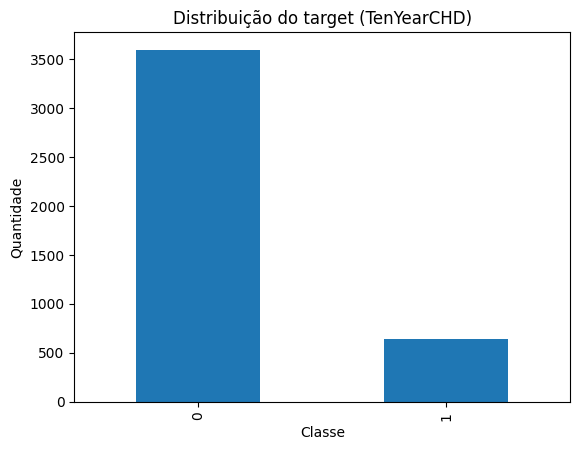

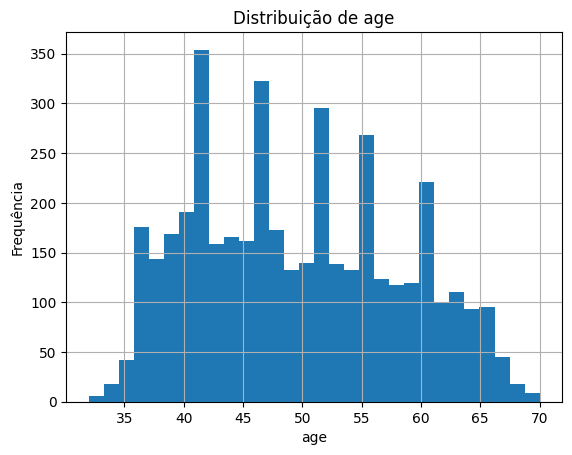

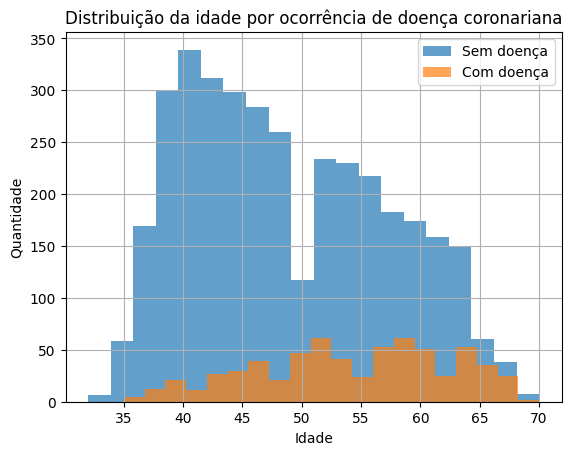

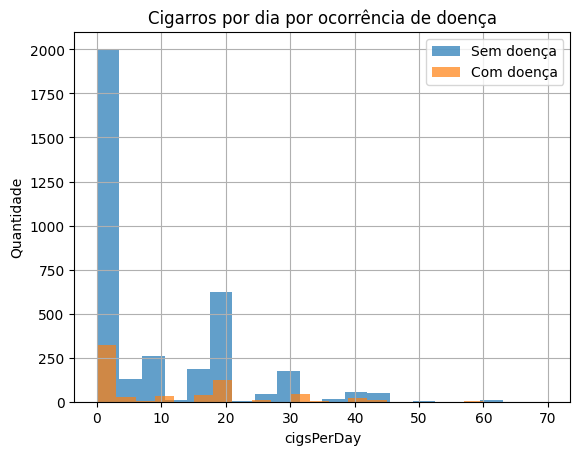

In [9]:
# Exemplos simples de visualização. Adapte para seu dataset.

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

df["TenYearCHD"].value_counts().plot(kind="bar")
plt.title("Distribuição do target (TenYearCHD)")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

if TARGET in numeric_cols:
    numeric_cols_without_target = [c for c in numeric_cols if c != TARGET]
else:
    numeric_cols_without_target = numeric_cols

if numeric_cols_without_target:
    col = "age"
    df[col].hist(bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

if categorical_cols:
    col = categorical_cols[0]
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.show()

df[df["TenYearCHD"] == 0]["age"].hist(alpha=0.7, bins=20, label="Sem doença")
df[df["TenYearCHD"] == 1]["age"].hist(alpha=0.7, bins=20, label="Com doença")

plt.title("Distribuição da idade por ocorrência de doença coronariana")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

df[df["TenYearCHD"] == 0]["cigsPerDay"].hist(alpha=0.7, bins=20, label="Sem doença")
df[df["TenYearCHD"] == 1]["cigsPerDay"].hist(alpha=0.7, bins=20, label="Com doença")

plt.title("Cigarros por dia por ocorrência de doença")
plt.xlabel("cigsPerDay")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

## 4.1 Síntese da análise exploratória

Escreva aqui os principais achados da EDA.

**Exemplo de perguntas para responder:**
- O target está balanceado?
- Existem valores ausentes relevantes?
- Há variáveis com escala muito diferente?
- Há categorias raras?
- Existem padrões que sugerem quais modelos podem funcionar melhor?
- Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?

**Síntese:**  
> A análise exploratória mostrou que a variável alvo (TenYearCHD) apresenta desbalanceamento moderado, com aproximadamente 84,8% dos registros pertencentes à classe 0 (sem ocorrência de doença coronariana em 10 anos) e 15,2% à classe 1 (com ocorrência da doença). Dessa forma, além da acurácia, serão utilizadas métricas como F1-score e ROC-AUC para uma avaliação mais adequada dos modelos.
A distribuição da idade indica concentração dos indivíduos entre aproximadamente 35 e 65 anos. Ao relacionar idade e ocorrência de doença coronariana, observou-se maior concentração de casos positivos em indivíduos mais velhos, sugerindo que a variável age possui relevância preditiva e deverá contribuir para o desempenho dos modelos de classificação.
A variável cigsPerDay apresentou grande concentração de indivíduos não fumantes ou com baixo consumo de cigarros. Embora o tabagismo seja reconhecido como fator de risco cardiovascular, a separação visual entre as classes não foi tão evidente quanto na variável idade. Ainda assim, a variável será mantida para que sua contribuição seja avaliada durante o treinamento dos modelos.
Também foram identificados valores ausentes em algumas variáveis do conjunto de dados, indicando a necessidade de tratamento por imputação na etapa de pré-processamento. Além disso, foram observados alguns valores extremos em determinadas variáveis, que serão avaliados para verificar seu impacto na modelagem. Não foram encontrados registros duplicados.
Com base nos resultados obtidos, espera-se que variáveis relacionadas à idade e aos fatores de risco cardiovascular tenham papel importante na previsão da ocorrência de doença coronariana em 10 anos.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [10]:
# === Configuração do problema ===
# Ajuste estas variáveis para o seu dataset.

TARGET = "TenYearCHD"                  # para clusterização, use None
PROBLEM_TYPE = "classificacao"    # "classificacao", "regressao", "clusterizacao" ou "serie_temporal"
ID_COLUMNS = []                    # ex.: ["id_cliente"]
DATE_COLUMN = None                 # ex.: "data"; necessário para séries temporais
DROP_COLUMNS = []                  # colunas a remover por vazamento, irrelevância ou indisponibilidade no uso real

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: TenYearCHD
Número de features: 15
Features: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


In [11]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (3390, 15) | Teste: (848, 15)


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> Foi utilizada a estratégia holdout, com separação de 80% dos dados para treinamento e 20% para teste. Não foi utilizada divisão temporal, pois o dataset não possui uma variável de tempo, e a validação cruzada será utilizada posteriormente apenas para comparação e ajuste dos modelos.
A proporção 80/20 foi escolhida por ser adequada ao tamanho da base (4.238 registros), permitindo que o modelo seja treinado com uma quantidade suficiente de exemplos sem comprometer a avaliação em dados não vistos.
Como o problema é de classificação binária e a variável alvo (TenYearCHD) apresenta desbalanceamento (84,8% dos pacientes não desenvolveram doença coronariana e 15,2% desenvolveram), foi utilizada a estratificação das classes (stratify=y). Dessa forma, a proporção das classes é preservada tanto no conjunto de treinamento quanto no conjunto de teste.
A divisão evita vazamento de dados porque a variável alvo foi separada das variáveis preditoras antes do treinamento e os dados de teste permanecerão isolados durante o processo de construção dos modelos, sendo utilizados apenas para avaliação final do desempenho


# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [12]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Colunas categóricas: []


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
Como o dataset apresenta valores ausentes em algumas variáveis, foi definida a imputação pela mediana para todas as colunas numéricas. A mediana foi escolhida por ser menos sensível a valores extremos do que a média, característica importante em variáveis clínicas como glicose, colesterol, pressão arterial e índice de massa corporal.

Também foi aplicada a padronização das variáveis numéricas por meio do StandardScaler. Essa etapa coloca os atributos em uma mesma escala, evitando que variáveis com amplitudes maiores exerçam influência desproporcional durante o treinamento dos modelos.

Não foi necessário realizar codificação de variáveis categóricas, pois todas as variáveis da base já estavam representadas numericamente. Embora algumas delas sejam binárias (como diabetes, currentSmoker e prevalentHyp), elas já se encontram em formato adequado para utilização pelos algoritmos.

Nenhuma variável foi removida nesta etapa e não foram criadas novas variáveis. Todas as 15 variáveis preditoras foram mantidas por apresentarem potencial relevância para a previsão da ocorrência de doença coronariana em dez anos. Além disso, todas as informações utilizadas estão disponíveis no momento da previsão, permitindo a aplicação do modelo em cenários reais.


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [31]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
Foi utilizado um DummyClassifier como modelo baseline, cuja estratégia consiste em prever sempre a classe mais frequente. Esse modelo serve como referência mínima de desempenho, permitindo verificar se os modelos de Machine Learning realmente aprenderam padrões relevantes dos dados ou apenas se beneficiaram do desbalanceamento das classes.

Como modelos candidatos foram escolhidos a Regressão Logística e o Random Forest. A Regressão Logística é uma abordagem amplamente utilizada em problemas de classificação binária, como a previsão da ocorrência de doença coronariana em dez anos. Além de apresentar baixo custo computacional, oferece boa interpretabilidade, permitindo analisar a influência das variáveis sobre a probabilidade de ocorrência do evento.

O Random Forest foi selecionado por sua capacidade de capturar relações não lineares e interações complexas entre as variáveis clínicas e demográficas presentes no dataset. Esse modelo costuma apresentar bom desempenho em bases tabulares e é mais robusto a ruídos e overfitting do que árvores de decisão individuais.

A Regressão Logística se beneficia da padronização realizada no pré-processamento, enquanto o Random Forest é menos sensível à escala das variáveis. Dessa forma, a comparação entre os dois modelos permite avaliar tanto uma abordagem mais simples e interpretável quanto uma abordagem mais flexível e potencialmente mais precisa.

Como o dataset possui tamanho moderado (4.238 registros), ambos os modelos podem ser treinados com baixo custo computacional, tornando viável a comparação de desempenho utilizando as métricas definidas para o projeto.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [33]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.847877,0.778078,0.500000,0.015
LogisticRegression,0.849057,0.793037,0.695507,0.018
RandomForest,0.845519,0.779102,0.628063,0.673


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
Os resultados mostram que ambos os modelos de Machine Learning superaram o baseline, principalmente quando analisada a métrica ROC-AUC. Embora a acurácia dos modelos tenha permanecido próxima à do baseline, isso era esperado devido ao desbalanceamento da variável alvo, em que aproximadamente 85% dos registros pertencem à classe "sem doença".

A Regressão Logística apresentou o melhor desempenho geral, alcançando ROC-AUC de aproximadamente 0,70 e F1-score superior ao baseline. Esse resultado indica que o modelo conseguiu aprender padrões relevantes dos dados e diferenciar melhor os pacientes com maior risco de desenvolver doença coronariana.

O Random Forest também superou o baseline em ROC-AUC, porém apresentou desempenho inferior ao da Regressão Logística. Isso sugere que, nesta configuração inicial e sem ajuste de hiperparâmetros, a abordagem linear foi mais adequada para capturar os padrões presentes na base de dados.

Os tempos de treinamento foram baixos para todos os modelos, demonstrando que o tamanho do dataset é compatível com as técnicas escolhidas. Além disso, os resultados observados fazem sentido quando comparados à análise exploratória, que indicou relação entre idade, tabagismo e ocorrência da doença coronariana.

Como próximos passos, podem ser avaliadas estratégias de ajuste de hiperparâmetros e tratamento do desbalanceamento das classes para verificar se é possível melhorar a capacidade de identificação dos casos positivos.


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [34]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.7957194445842086
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
Foi realizada uma otimização de hiperparâmetros utilizando o algoritmo Random Forest em conjunto com o método RandomizedSearchCV. A validação foi feita por meio de validação cruzada estratificada com 5 folds, garantindo que a proporção das classes fosse mantida em cada divisão do conjunto de treinamento. Como métrica de avaliação foi utilizado o F1-score ponderado, por ser mais adequado para um problema de classificação com classes desbalanceadas.

A busca avaliou diferentes combinações dos hiperparâmetros n_estimators (número de árvores), max_depth (profundidade máxima das árvores) e min_samples_split (número mínimo de amostras para realizar uma divisão). A melhor configuração encontrada foi n_estimators = 121, max_depth = 16 e min_samples_split = 4, alcançando um F1-score médio de validação de aproximadamente 0,796.

Os resultados indicam que a configuração otimizada apresentou desempenho satisfatório na identificação dos casos de doença coronariana, demonstrando capacidade de generalização durante a validação cruzada. Além disso, os hiperparâmetros selecionados sugerem um equilíbrio entre complexidade do modelo e capacidade de aprendizado dos padrões presentes nos dados.

A busca foi limitada a apenas 5 combinações de hiperparâmetros, o que permitiu manter baixo custo computacional e tempo de execução reduzido. Mesmo com uma quantidade limitada de testes, foi possível encontrar uma configuração com desempenho competitivo, demonstrando que a estratégia adotada foi suficiente para explorar diferentes configurações do modelo e identificar uma alternativa promissora.


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Tempo de treino do modelo final: 0.728 s
Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       719
           1       0.60      0.02      0.04       129

    accuracy                           0.85       848
   macro avg       0.73      0.51      0.48       848
weighted avg       0.81      0.85      0.79       848



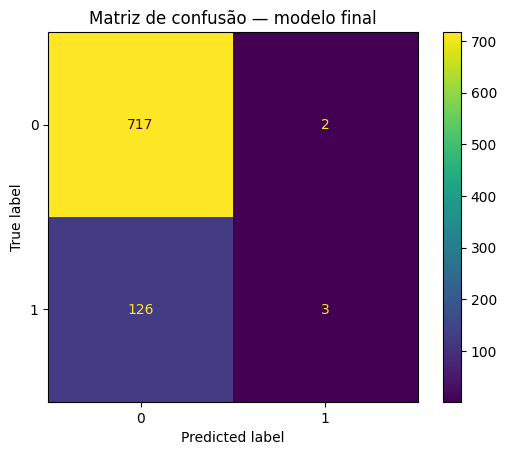

In [41]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
    import time

    t0 = time.time()
    final_model.fit(X_train, y_train)
    tempo_final = time.time() - t0

    print(f"Tempo de treino do modelo final: {tempo_final:.3f} s")

elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
O modelo final apresentou acurácia de 85%, indicando boa capacidade de classificação geral. Entretanto, a análise detalhada da matriz de confusão mostra que o desempenho não foi equilibrado entre as classes.

O principal erro observado foi a alta quantidade de falsos negativos. Dos 129 pacientes que realmente desenvolveriam doença coronariana, apenas 3 foram corretamente identificados pelo modelo, enquanto 126 foram classificados como saudáveis. Esse comportamento resultou em um recall de apenas 0,02 para a classe positiva.

Não foram observados indícios claros de overfitting nesta etapa. Entretanto, o baixo recall da classe positiva sugere que o modelo ainda não conseguiu capturar adequadamente os padrões associados aos pacientes que desenvolvem doença coronariana.

Embora a acurácia tenha alcançado 85%, essa métrica isoladamente não representa adequadamente o objetivo do problema, pois a base é desbalanceada. Nesse contexto, métricas como Recall, F1-score e ROC-AUC fornecem uma avaliação mais adequada da capacidade do modelo de identificar pacientes em risco.

Os resultados indicam que o modelo foi fortemente influenciado pelo desbalanceamento da base de dados, na qual a maioria dos exemplos pertence à classe de pacientes sem doença. Isso pode limitar sua capacidade de generalização para novos casos e reduzir sua utilidade prática.

Dessa forma, o modelo não deve ser utilizado como ferramenta única para apoio à decisão clínica, pois apresenta baixa capacidade de identificar pacientes que realmente desenvolverão doença coronariana. Como trabalhos futuros, poderiam ser avaliadas técnicas de balanceamento de classes, ajuste de pesos, oversampling (SMOTE) e novos algoritmos para melhorar a identificação dos casos positivos.


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal (F1-Score) | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | 0,778 | Accuracy = 0,848; ROC-AUC = 0,500 | 0,015 s | Modelo de referência que prevê a classe mais frequente. |
| Logistic Regression | 0,793 | Accuracy = 0,849; ROC-AUC = 0,696 | 0,018 s | Melhor desempenho entre os modelos candidatos, com maior capacidade de discriminação das classes. |
| Random Forest | 0,779 | Accuracy = 0,846; ROC-AUC = 0,628 | 0,673 s | Desempenho semelhante ao baseline, sem ganho expressivo nas métricas. |
| Modelo otimizado | 0,796 (validação cruzada) | Accuracy = 0,850; Recall classe 1 = 0,02 | 0,728 s | Melhor configuração encontrada na busca de hiperparâmetros, porém apresentou dificuldade em identificar corretamente os casos positivos no conjunto de teste. |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
